In [31]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [32]:
d = pd.read_csv('../data/raw/training.csv')

In [33]:
# d['day'] = d['contactStart'].astype('datetime64[ns]')
# count = 0
# for i in d['day'].dt.dayofweek:
#     if i == 5:
#         count = count + 1
#     if i == 6:
#         count = count + 1
# print(f'Total Saturdays and Sundays: {count}')
# d['day'].replace(5,np.NaN,inplace=True)
# d['day'].replace(6,np.NaN,inplace=True)
# print('Number of Saturday and Sunday obersvations: ', d['day'].isnull().sum())
# d.dropna(inplace=True)
# print('...Removed')

In [34]:
# Create timestamp interval
temp_callstart = []
for i in d['contactStart'].astype('datetime64[ns]'):
    if i.minute < 30:
        lt = i.replace(minute=0, second=0, microsecond=0)
        temp_callstart.append(lt)
    elif i.minute >= 30:
        gte = i.replace(minute=30, second=0, microsecond=0)
        temp_callstart.append(gte)

d['timestamp'] = temp_callstart

In [35]:
count = 0
for i in d['agentSeconds']:
    if i == 0:
        count = count + 1
print(f'Agent Seconds equal to zero: {count}')
# d['agentSeconds'].replace(0, np.NaN,inplace=True)
# d.dropna(inplace=True)
# print('...Removed')

Agent Seconds equal to zero: 55955


In [36]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650698 entries, 0 to 650697
Data columns (total 9 columns):
Unnamed: 0        650698 non-null int64
contactId         650698 non-null int64
contactStart      650698 non-null object
campaignId        650698 non-null int64
abandoned         650698 non-null int64
abandonseconds    650698 non-null int64
inQueueSeconds    650698 non-null int64
agentSeconds      650698 non-null int64
timestamp         650698 non-null datetime64[ns]
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 44.7+ MB


In [37]:
# Query groups
call_volume = d.groupby(['timestamp'])['contactStart'].count()
avg_handle_time = d.groupby(['timestamp'])['agentSeconds'].mean()
avg_queue_time = d.groupby(['timestamp'])['inQueueSeconds'].mean()
avg_aband_time = d.groupby(['timestamp'])['abandonseconds'].mean()

In [38]:
print(f'Call Volume Length:\t\t {len(call_volume)}')
print(f'Avg. Handle Time Length:\t {len(avg_handle_time)}')
print(f'Avg Queue Time:\t\t\t {len(avg_queue_time)}')
print(f'Avg Queue Time:\t\t\t {len(avg_aband_time)}')

Call Volume Length:		 3035
Avg. Handle Time Length:	 3035
Avg Queue Time:			 3035
Avg Queue Time:			 3035


In [39]:
CV = [] # Call volume
for i in call_volume:
    CV.append(i)
    
AHT = []
for i in avg_handle_time:
    AHT.append(i)
    
AQT = []
for i in avg_queue_time:
    AQT.append(i)
    
AAT = []
for i in avg_aband_time:
    AAT.append(i)

***

In [40]:
# New Dateframe
train = pd.DataFrame()
train['CV'] = CV
train['time'] = d['timestamp'].unique()
train['AHT'] = AHT
# train['AQT'] = AQT
# train['AAT'] = AAT

train['AHT'].replace(0, np.NaN, inplace=True) # Remnove AHT = 0
train.dropna(inplace=True)

# train['month'] = train.time.dt.month
# train['minute'] = train.time.dt.minute

In [41]:
train['time24'] = train.time.dt.time.astype('category')
train['hour'] = train.time.dt.hour
train['day'] = train.time.dt.dayofweek

In [42]:
print(f'Dimsension: {train.shape}')

Dimsension: (1843, 6)


In [43]:
print(f'Dimsension: {train.shape}')

Dimsension: (1843, 6)


In [44]:
# train['day'].replace(0,'M',inplace=True)
# train['day'].replace(1,'TU',inplace=True)
# train['day'].replace(2,'W',inplace=True)
# train['day'].replace(3,'TH',inplace=True)
# train['day'].replace(4,'F',inplace=True)

# train['day'].replace(5,'SAT',inplace=True)
# train['day'].replace(6,'SUN',inplace=True)
# train.isnull().sum()
# train.dropna(inplace=True)
# train.reset_index(inplace=True, drop=True)

***

In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1843 entries, 1 to 3031
Data columns (total 6 columns):
CV        1843 non-null int64
time      1843 non-null datetime64[ns]
AHT       1843 non-null float64
time24    1843 non-null category
hour      1843 non-null int64
day       1843 non-null int64
dtypes: category(1), datetime64[ns](1), float64(1), int64(3)
memory usage: 89.6 KB


In [ ]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['day'], train['CV'])
plt.xlabel('Day', fontsize=14)
plt.ylabel('Call Volume', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['time24'], train['CV'])
plt.xlabel('time24', fontsize=14)
plt.ylabel('Call Volume', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['CV'])
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Call Volume', fontsize=14)
plt.show()

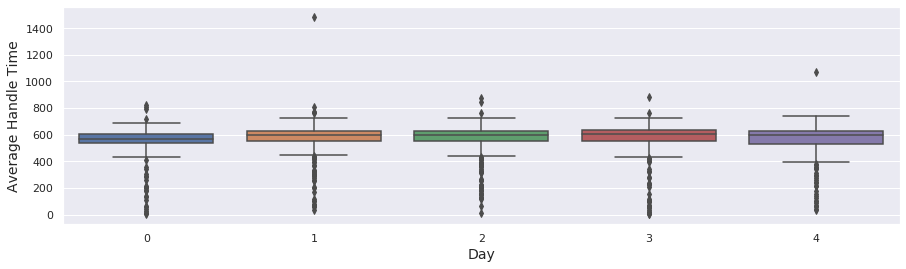

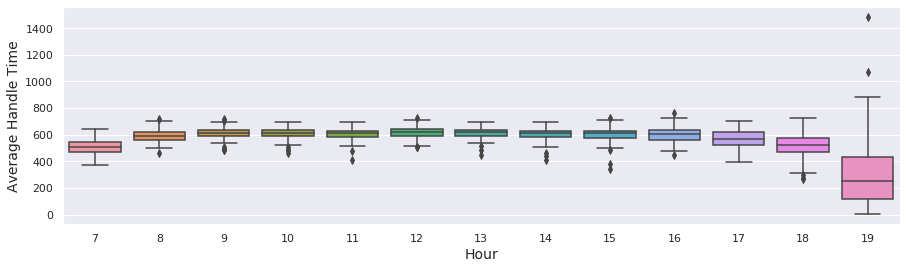

In [17]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['day'], train['AHT'])
plt.xlabel('Day', fontsize=14)
plt.ylabel('Average Handle Time', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['AHT'])
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Average Handle Time', fontsize=14)
plt.show()

In [18]:
# plt.subplots(figsize=(15, 4))
# sns.boxplot(train['day'], train['AQT'])
# plt.xlabel('Day', fontsize=14)
# plt.ylabel('Average Handle Time', fontsize=14)
# plt.show()

# plt.subplots(figsize=(15, 4))
# sns.boxplot(train['hour'], train['AQT'])
# plt.xlabel('Hour', fontsize=14)
# plt.ylabel('Average Queue Time', fontsize=14)
# plt.show()

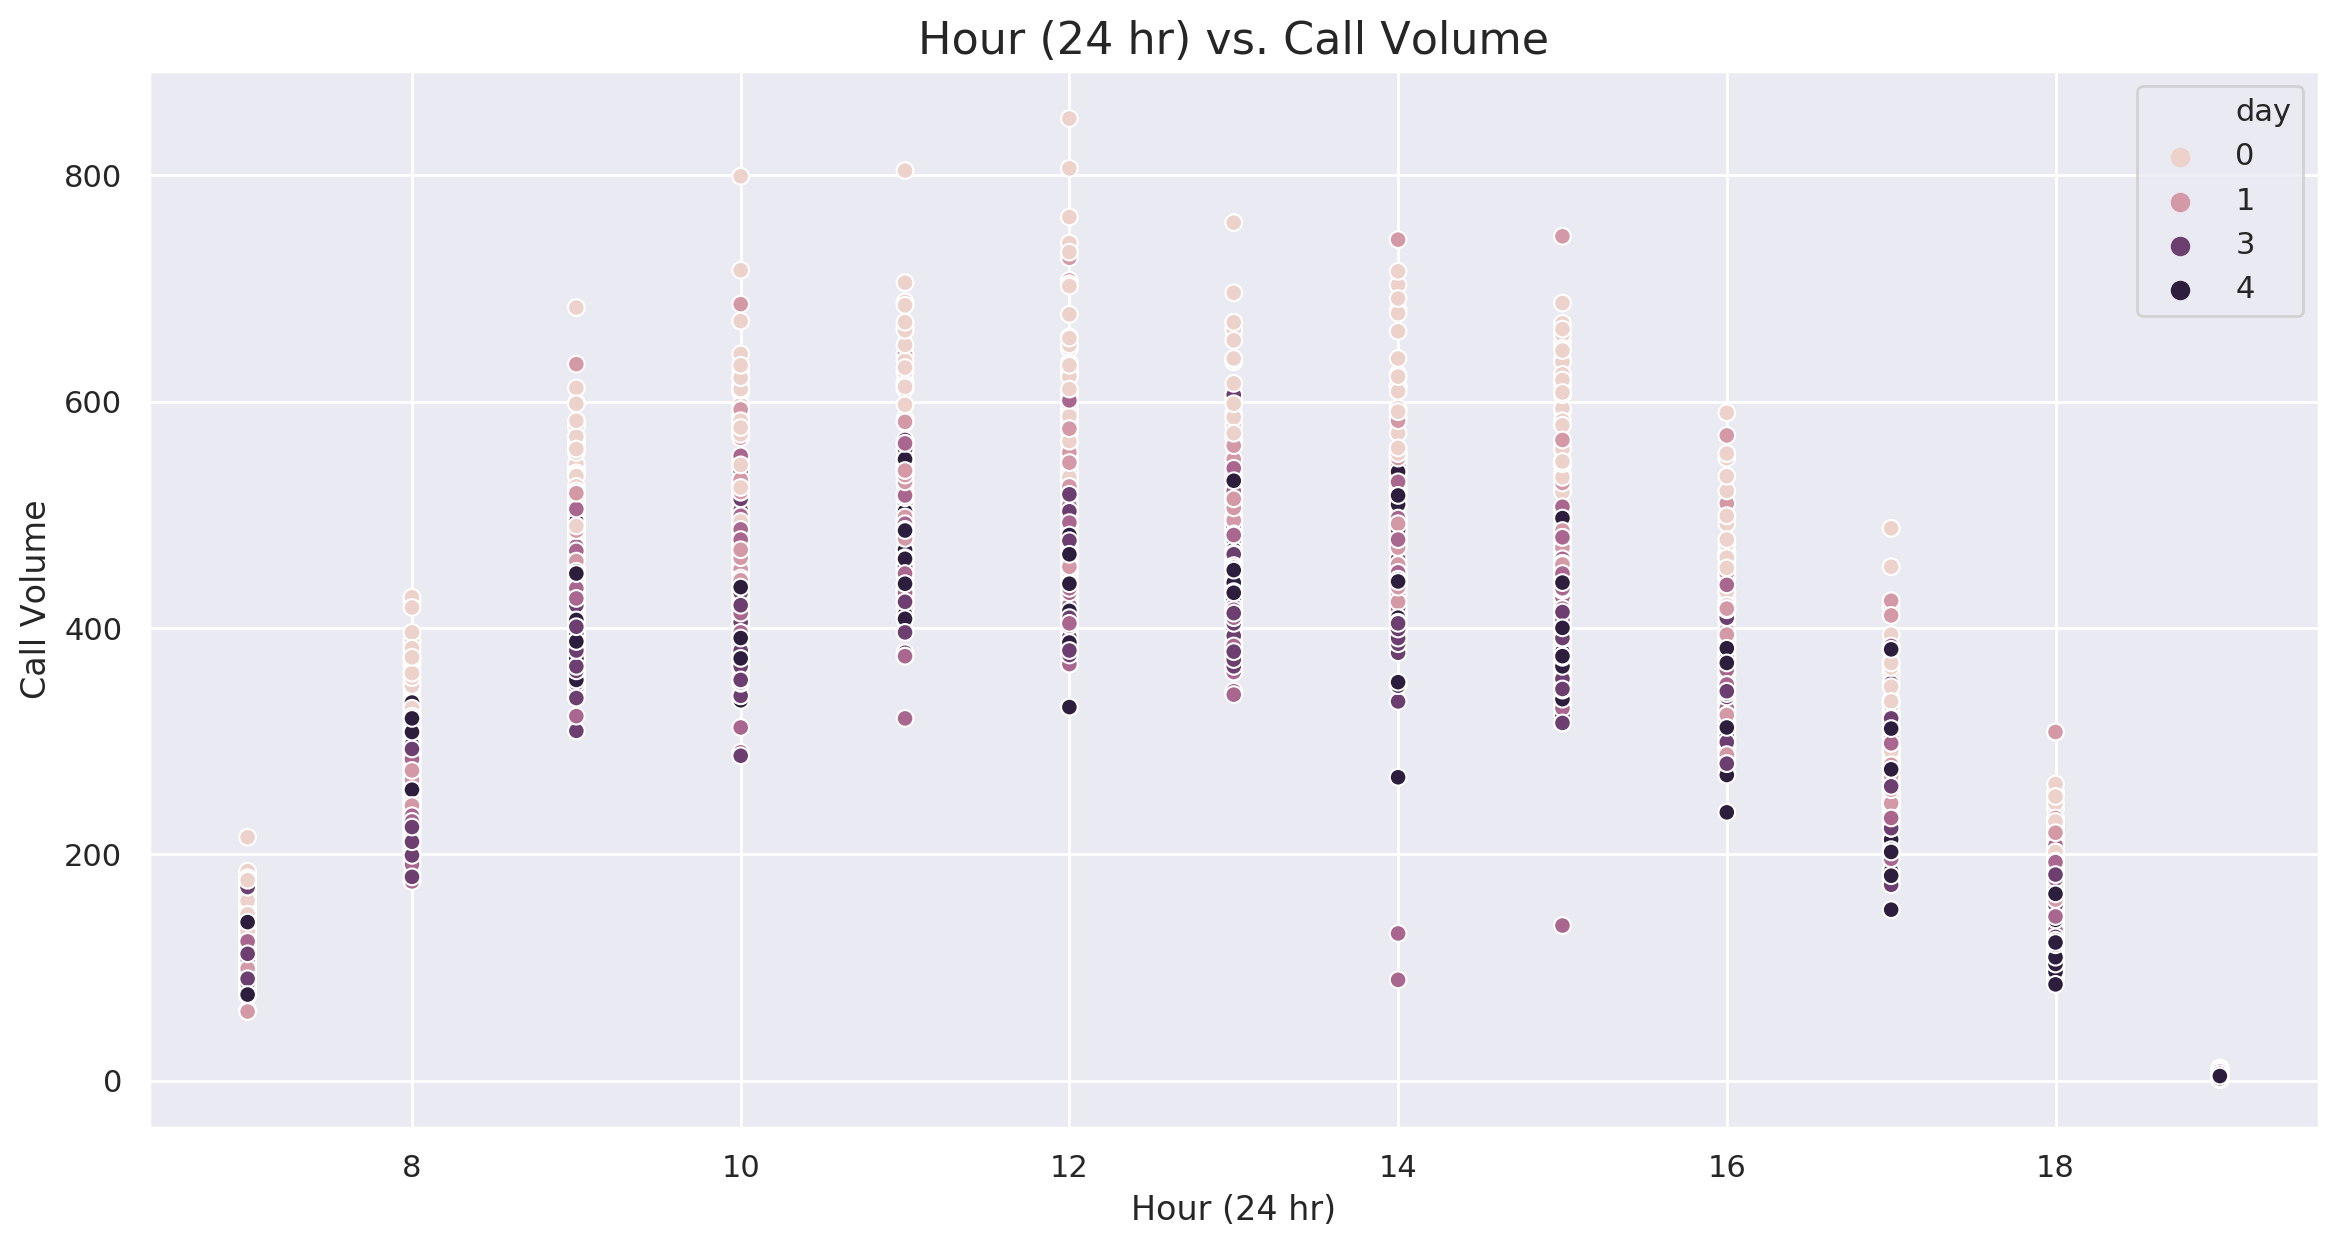

In [19]:
fig, ax = plt.subplots(figsize=(14,7), dpi=200)
sns.scatterplot(x="hour", y="CV", hue="day", data=train)
plt.title('Hour (24 hr) vs. Call Volume', fontsize=16)
ax.set_xlabel('Hour (24 hr)')
ax.set_ylabel('Call Volume')
plt.show()

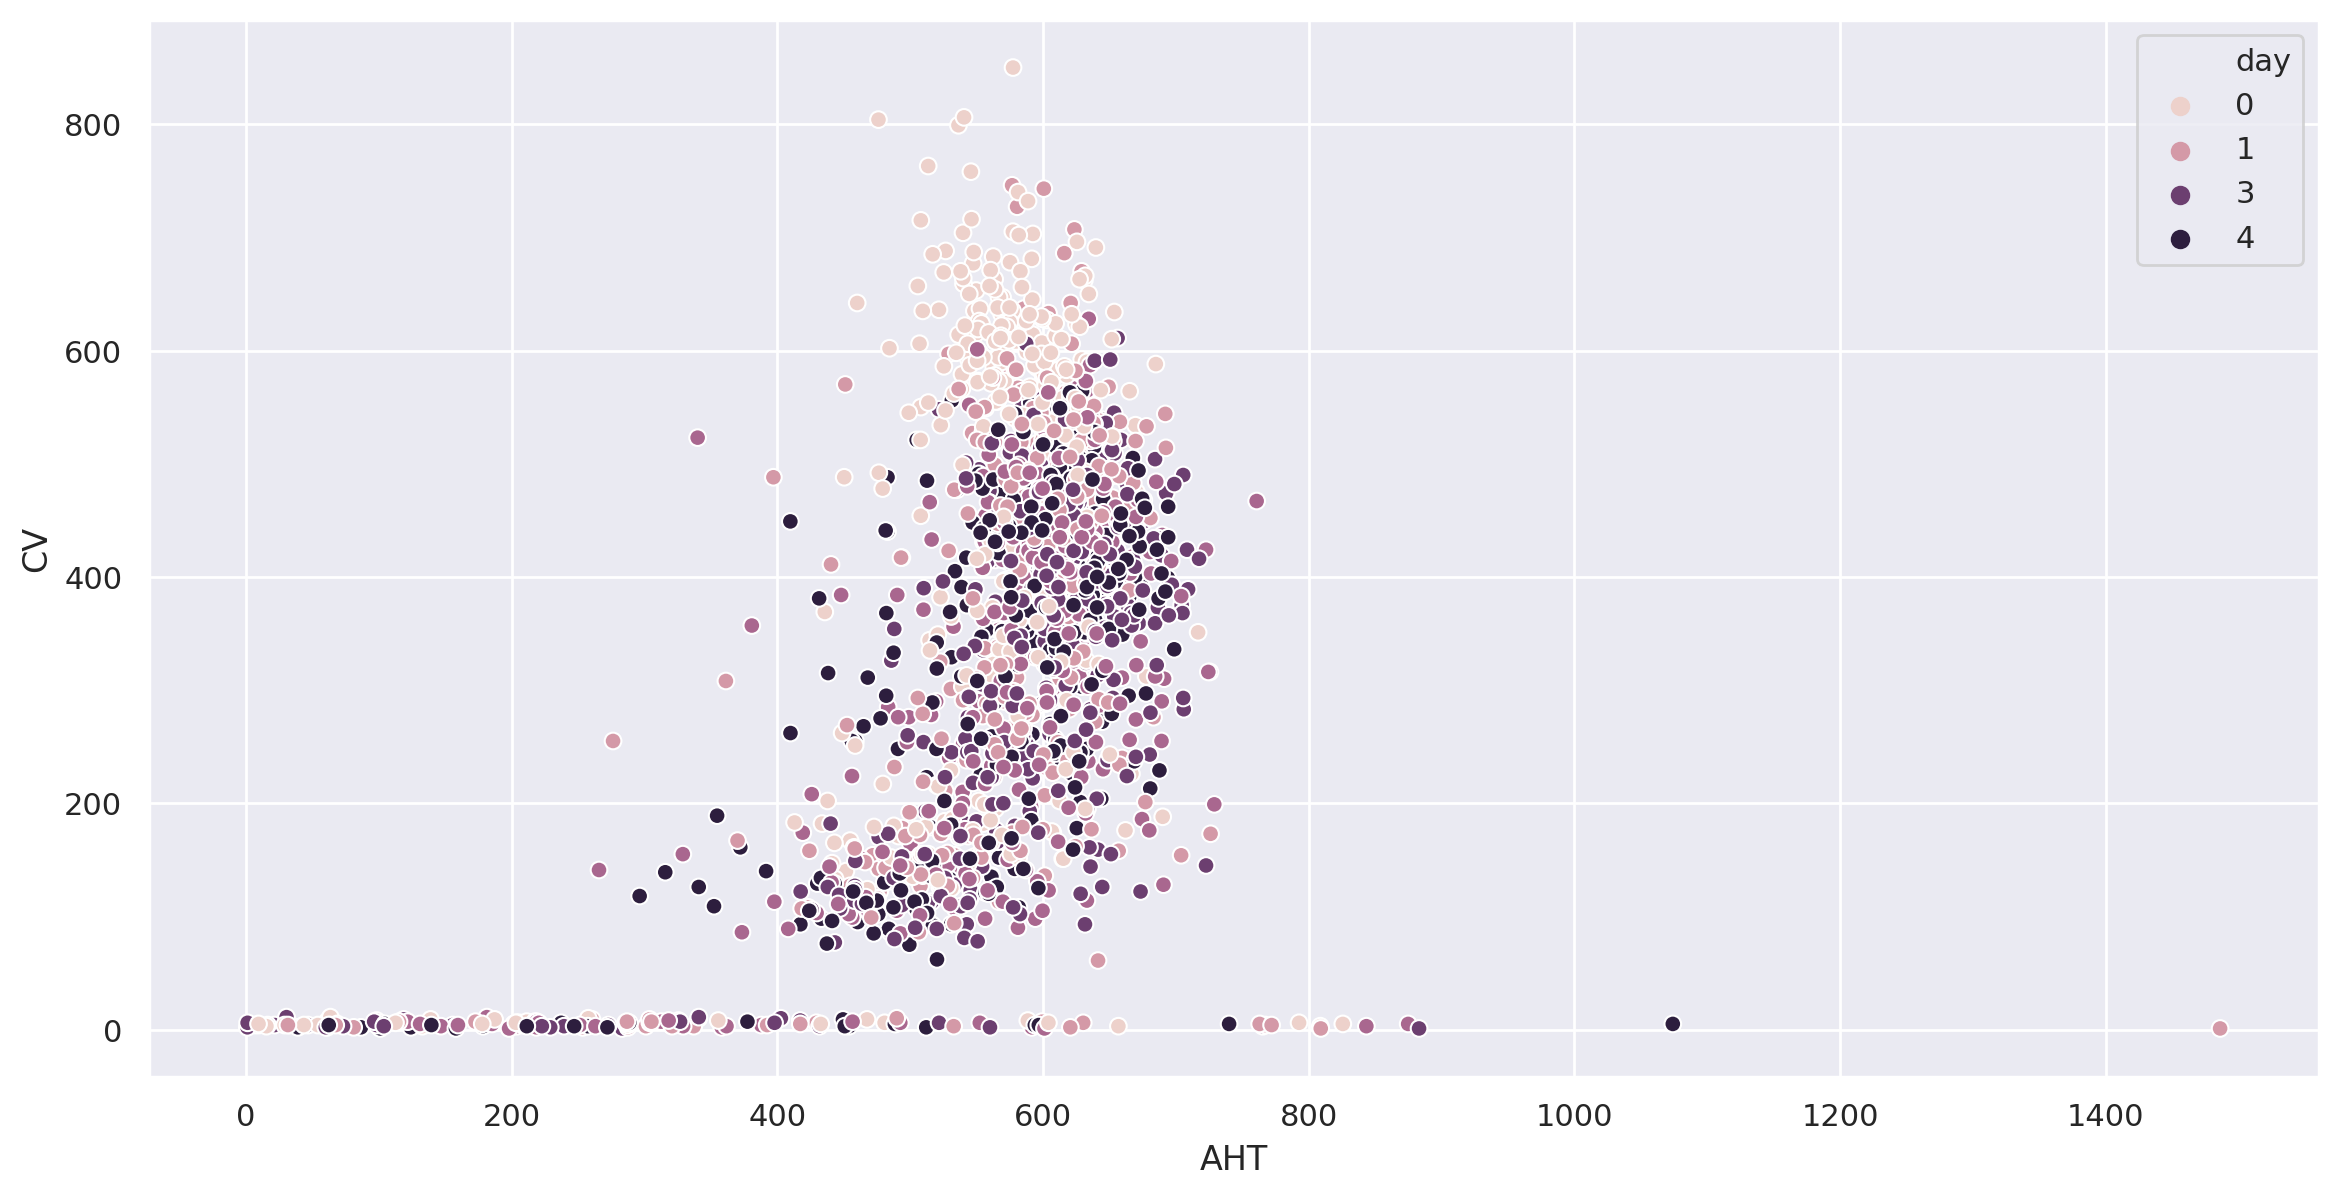

In [20]:
fig, ax = plt.subplots(figsize=(14,7), dpi=200)
sns.scatterplot(x='AHT', y='CV', data=train, hue='day')
plt.show()

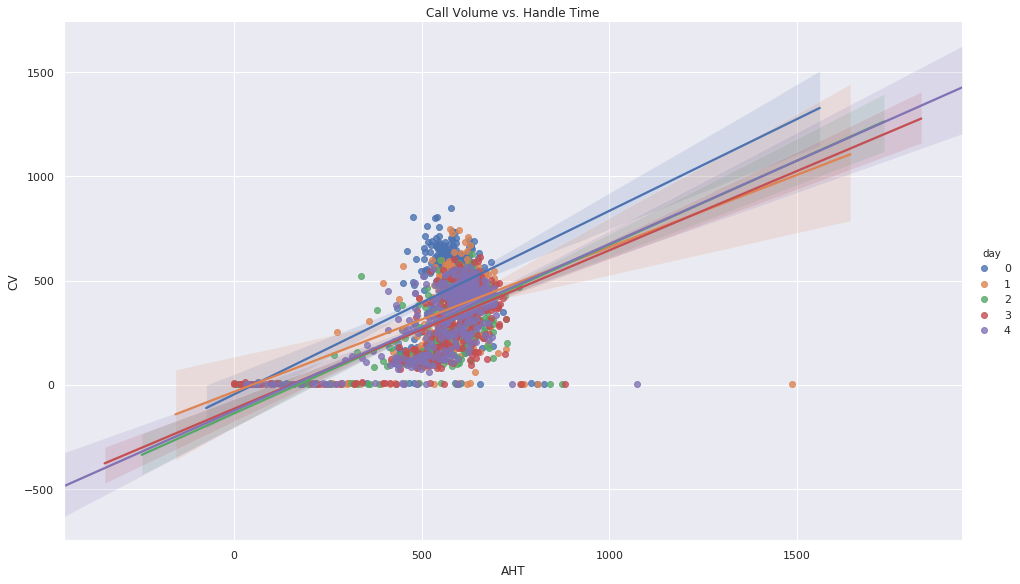

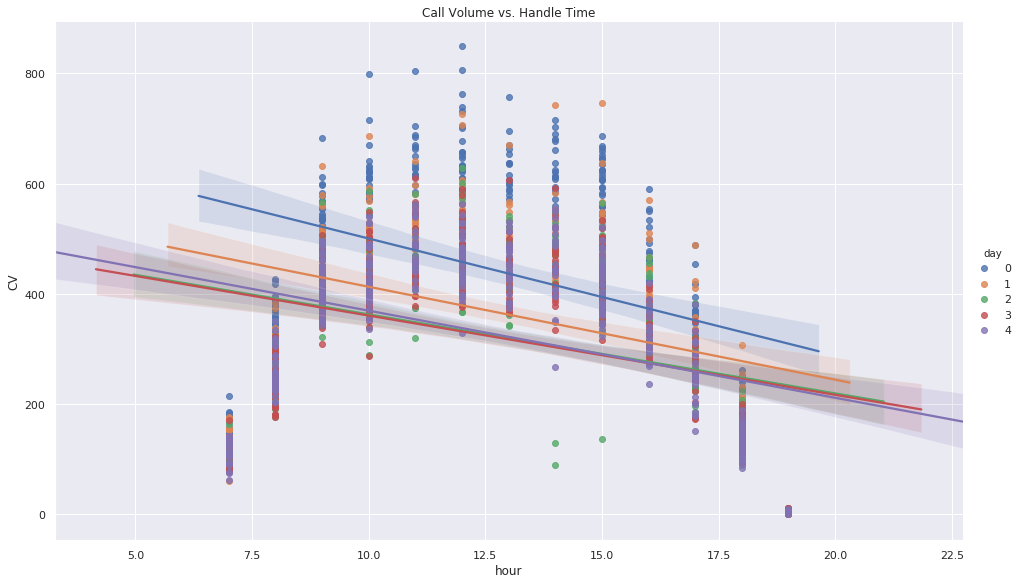

In [21]:
sns.lmplot(x='AHT', y='CV', data=train,
           fit_reg=True, hue='day', height=8, aspect=1.7)
plt.title('Call Volume vs. Handle Time')
plt.show()

sns.lmplot(x='hour', y='CV', data=train,
           fit_reg=True, hue='day', height=8, aspect=1.7)
plt.title('Call Volume vs. Handle Time')
plt.show()

In [22]:
# Output CSV to begin modeling
train.to_csv('../data/interim/02training.csv')

In [23]:
train_key = pd.read_csv('../data/raw/answer.csv')

In [24]:
train_key.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2245 entries, 0 to 2244
Data columns (total 8 columns):
Unnamed: 0                        2245 non-null int64
timerounded                       2245 non-null object
AVG(inQueueSeconds)               2245 non-null float64
summary2$`AVG(abandonseconds)`    2245 non-null float64
summary3$`AVG(abandoned)`         2245 non-null float64
summary4$`COUNT(campaignId)`      2245 non-null int64
CallVolume                        2245 non-null int64
HandleTime                        2245 non-null int64
dtypes: float64(3), int64(4), object(1)
memory usage: 140.4+ KB


In [25]:
# train_key.info()

In [26]:
train_key.head()
# train_key.describe()

,Unnamed: 0,timerounded,AVG(inQueueSeconds),summary2$`AVG(abandonseconds)`,summary3$`AVG(abandoned)`,summary4$`COUNT(campaignId)`,CallVolume,HandleTime
0,1,2018-05-01 07:00:00,3.841463,0.0,0.0,82,0,0
1,2,2018-05-01 07:30:00,1.414634,0.0,0.0,123,0,0
2,3,2018-05-01 08:00:00,2.457746,0.0,0.0,284,0,0
3,4,2018-05-01 08:30:00,5.559271,0.0,0.0,329,0,0
4,5,2018-05-01 09:00:00,15.993166,0.0,0.0,439,0,0


In [27]:
train.head()

,CV,time,AHT,time24,hour,day
1,127,2018-05-01 07:30:00,507.692913,07:30:00,7,1
2,290,2018-05-01 08:00:00,570.900000,08:00:00,8,1
3,338,2018-05-01 08:30:00,565.769231,08:30:00,8,1
4,466,2018-05-01 09:00:00,572.927039,09:00:00,9,1
5,580,2018-05-01 09:30:00,567.168966,09:30:00,9,1
